<a href="https://colab.research.google.com/github/tuonglong1012/sgu25-khaiphadulieu/blob/Phuong-final/Challenge_1(P).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
# Nếu bạn muốn lưu repo vào Drive (không mất sau khi tắt Colab)
from google.colab import drive
drive.mount('/content/drive')

# Chuyển đến thư mục Drive (tùy ý)
%cd /content/drive/MyDrive/Colab Notebooks



# Di chuyển vào thư mục vừa clone
%cd sgu25-khaiphadulieu

# Kiểm tra các file trong branch
!ls


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Colab Notebooks
/content/drive/MyDrive/Colab Notebooks/sgu25-khaiphadulieu
adaboost_pipeline.joblib
bagging_pipeline.joblib
challenge_1_titanic
classification_report_Voting_Ensemble_20251101_140757.txt
classification_report_Voting_Ensemble_20251101_141149.txt
classification_report_Voting_Ensemble_20251101_174436.txt
classification_report_Voting_Ensemble_20251101_174700.txt
confusion_matrix_Voting_Ensemble_20251101_140757.png
confusion_matrix_Voting_Ensemble_20251101_141149.png
confusion_matrix_Voting_Ensemble_20251101_174436.png
confusion_matrix_Voting_Ensemble_20251101_174700.png
dt_tuned_pipeline.joblib
html_logs
logreg_tuned_pipeline.joblib
randomforest_pipeline.joblib
test_predictions.csv
titanic_final_model.joblib
titanic_final_model_log.txt
voting_pipeline.joblib


In [19]:


# Kiểm tra xem các file đã có chưa
!find /content/drive/MyDrive -name "titanic_after_P1.pkl"
!find /content/drive/MyDrive -name "titanic_logreg_baseline.joblib"
!find /content/drive/MyDrive -name "cart_pipeline_model.pkl"



/content/drive/MyDrive/Colab Notebooks/titanic_after_P1.pkl
/content/drive/MyDrive/Colab Notebooks/sgu25-khaiphadulieu/challenge_1_titanic/titanic_logreg_baseline.joblib
/content/drive/MyDrive/sgu25-khaiphadulieu/challenge_1_titanic/titanic_logreg_baseline.joblib
/content/drive/MyDrive/Colab Notebooks/sgu25-khaiphadulieu/challenge_1_titanic/cart_pipeline_model.pkl
/content/drive/MyDrive/sgu25-khaiphadulieu/challenge_1_titanic/cart_pipeline_model.pkl


In [20]:
import joblib
import pandas as pd

# Load dữ liệu đã xử lý ở P1
train_df, test_df = joblib.load('/content/drive/MyDrive/Colab Notebooks/titanic_after_P1.pkl')

print("✅ [LOG] Đã load dữ liệu sau P1!")
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)


✅ [LOG] Đã load dữ liệu sau P1!
Train shape: (714, 12)
Test shape: (332, 10)


In [21]:
# ===== FIX FARE_CATEGORY CHO TEST  =====

import pandas as pd

# Bins đúng chuẩn qcut của Híu
fare_bins = train_df['Fare'].quantile([0, 0.25, 0.5, 0.75, 1]).values

# Áp dụng bins này cho train và test
train_df['Fare_Category'] = pd.cut(train_df['Fare'], bins=fare_bins, include_lowest=True)
test_df['Fare_Category']  = pd.cut(test_df['Fare'], bins=fare_bins, include_lowest=True)

print("✅ Đã tái tạo Fare_Category cho TRAIN & TEST ")


✅ Đã tái tạo Fare_Category cho TRAIN & TEST 


In [22]:
# Import các class cần thiết
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Load mô hình baseline
logreg_model = joblib.load('/content/drive/MyDrive/Colab Notebooks/sgu25-khaiphadulieu/challenge_1_titanic/titanic_logreg_baseline.joblib')
cart_model = joblib.load('/content/drive/MyDrive/sgu25-khaiphadulieu/challenge_1_titanic/cart_pipeline_model.pkl')

print("✅ [LOG] Đã load 2 mô hình baseline thành công!")


✅ [LOG] Đã load 2 mô hình baseline thành công!


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid

#Phuong
* Huấn luyện cải thiện tham số
* Kết hợp mô hình
* Đánh giá và lưu


#Mã lưu tiến trình

In [23]:
import os
from datetime import datetime

# Tạo thư mục logs nếu chưa có
if not os.path.exists("html_logs"):
    os.makedirs("html_logs")

def save_html_log(title, content):
    """
    Tạo file HTML chứa toàn bộ nội dung log của cell vừa chạy.
    title: tên file (không dấu, không khoảng trắng)
    content: nội dung HTML/text để ghi vào file
    """
    filename = f"html_logs/{title}.html"
    html_template = f"""
    <html>
    <head>
        <meta charset="UTF-8">
        <title>{title}</title>
        <style>
            body {{ font-family: Arial; padding:20px; }}
            pre {{ background:#f4f4f4; padding:10px; border-radius:8px; }}
        </style>
    </head>
    <body>
        <h2>{title}</h2>
        <pre>{content}</pre>
    </body>
    </html>
    """
    with open(filename, "w", encoding="utf-8") as f:
        f.write(html_template)

    print("✅ Đã lưu log HTML:", filename)


##1. Huấn luyện cải thiện tham số


In [ ]:
#tạo lại preprocessor đúng với dataset
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

numeric_features = ['Age', 'SibSp', 'Parch', 'Fare']
categorical_features = ['Pclass', 'Sex', 'Embarked', 'Fare_Category']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)


In [24]:
#tạo lại preprocessor đúng với dataset
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

numeric_features = ['Age', 'SibSp', 'Parch', 'Fare']
categorical_features = ['Pclass', 'Sex', 'Embarked', 'Fare_Category']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)


*Ta xử lý FE 1 chút và đặt LogReg vào pipeline gồm preprocessor + model và dùng GridSearch (cv=5) để tìm tham số tối ưu.

In [25]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression

X = train_df[['Pclass','Sex','Age','SibSp','Parch','Fare','Embarked','Fare_Category']]
y = train_df['Survived']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

log_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

param_grid_log = {
    'model__C': [0.1, 1.0, 10.0],
}

log_grid = GridSearchCV(log_pipeline, param_grid_log, cv=5, scoring='accuracy')
log_grid.fit(X_train, y_train)

best_log_model = log_grid.best_estimator_
joblib.dump(best_log_model, "logreg_tuned_pipeline.joblib")

print("✅ DONE!")
print("Best params:", log_grid.best_params_)


✅ DONE!
Best params: {'model__C': 10.0}


1.1. Tuning Logistic Regression



* Logistic Regression baseline chỉ chạy với cấu hình mặc định → chưa tối ưu.

* Ta dùng GridSearchCV (5-fold cross-validation) để tìm hệ số C tốt nhất.

* Preprocessor xử lý numeric + categorical trước khi model fit.

In [26]:

# ==== CELL DEFINITIONS ====

# 1. Numeric theo dataset P1
numeric_features = ['Age', 'SibSp', 'Parch', 'Fare']

# 2. Categorical theo dataset P1
categorical_features = ['Pclass', 'Sex', 'Embarked', 'Fare_Category']

# 3. Features dùng cho training (X)
feature_cols = numeric_features + categorical_features

print("✅ feature_cols đã được định nghĩa lại cho P1 dataset:")
print(feature_cols)

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression

log_text = ">>> Tuning Logistic Regression\n\n"

# 1. Lấy X, y từ dữ liệu bước EDA
X = train_df[feature_cols]
y = train_df['Survived']

log_text += f"Using features: {feature_cols}\n\n"

# 2. Split thành train/val để đánh giá tuning
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

log_text += f"X_train shape: {X_train.shape}\n"
log_text += f"X_val shape: {X_val.shape}\n\n"

# 3. Pipeline Logistic Regression + preprocessor đã chuẩn hóa
log_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

# 4. Bộ tham số cần tuning
param_grid_log = {
    'model__C': [0.1, 1, 10],
}

# 5. GridSearchCV dùng 5-fold CV
grid = GridSearchCV(log_pipeline, param_grid_log, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

# 6. Lưu mô hình tốt nhất
best_log_model = grid.best_estimator_
joblib.dump(best_log_model, "logreg_tuned_pipeline.joblib")

log_text += f"Best params: {grid.best_params_}\n"
log_text += f"CV score: {grid.best_score_:.4f}\n"
log_text += "Saved: logreg_tuned_pipeline.joblib\n"

# 7. Lưu log HTML
title = datetime.now().strftime("%Y-%m-%d") + "_Tuning_LogisticRegression"
save_html_log(title, log_text)

print("✅ Logistic Regression tuning DONE")


✅ feature_cols đã được định nghĩa lại cho P1 dataset:
['Age', 'SibSp', 'Parch', 'Fare', 'Pclass', 'Sex', 'Embarked', 'Fare_Category']
✅ Đã lưu log HTML: html_logs/2025-11-02_Tuning_LogisticRegression.html
✅ Logistic Regression tuning DONE


1.2. Tuning Decision Tree





* Tối ưu mô hình Decision Tree để so sánh với Logistic Regression

In [27]:

from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.tree import DecisionTreeClassifier
from datetime import datetime

dt_text = ">>> CELL 4 — Tuning Decision Tree\n\n"

# 1) Lấy X, y từ dữ liệu sau P1
X = train_df[feature_cols]
y = train_df["Survived"]

dt_text += f"Số lượng feature: {len(feature_cols)}\n"
dt_text += f"Features dùng để train: {feature_cols}\n\n"

# 2) Tách train/val để đánh giá tuning
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

dt_text += f"X_train shape: {X_train.shape}\n"
dt_text += f"X_val shape: {X_val.shape}\n\n"

# 3) Pipeline Decision Tree
pipeline_dt = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier())
])

# 4) GridSearch parameters
dt_params = {
    'model__max_depth': [3, 5, 7, None],
    'model__min_samples_split': [2, 5, 10]
}

# 5) GridSearchCV
dt_grid = GridSearchCV(
    estimator=pipeline_dt,
    param_grid=dt_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

dt_grid.fit(X_train, y_train)

# 6) Lưu mô hình tốt nhất
best_dt_model = dt_grid.best_estimator_
joblib.dump(best_dt_model, "dt_tuned_pipeline.joblib")

dt_text += f"Best params: {dt_grid.best_params_}\n"
dt_text += f"Best CV score: {dt_grid.best_score_:.4f}\n"
dt_text += "Đã lưu mô hình: dt_tuned_pipeline.joblib\n"

# 7) Lưu HTML log
title = datetime.now().strftime("%Y-%m-%d") + "_Tuning_DecisionTree"
save_html_log(title, dt_text)

print("✅ CELL 4 DONE — Decision Tree tuning hoàn tất.")



✅ Đã lưu log HTML: html_logs/2025-11-02_Tuning_DecisionTree.html
✅ CELL 4 DONE — Decision Tree tuning hoàn tất.


#2. KẾT HỢP MÔ HÌNH

##2.1. Ensemble Bagging / RF / AdaBoost

* Huấn luyện 3 mô hình ensemble cổ điển để đánh giá mức cải thiện so với Logistic Regression & Decision Tree.

In [28]:

from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import cross_val_score
from datetime import datetime

ens_text = ">>> Ensemble Models\n\n"

# 1) Danh sách ensemble
models = {
    "Bagging": BaggingClassifier(),
    "RandomForest": RandomForestClassifier(n_estimators=100),
    "AdaBoost": AdaBoostClassifier(n_estimators=100)
}

# 2) Train + Cross-Validation
for name, clf in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', clf)
    ])

    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='accuracy')

    ens_text += f"{name}: {scores.mean():.4f} (+/- {scores.std():.4f})\n"

    pipe.fit(X_train, y_train)
    joblib.dump(pipe, f"{name.lower()}_pipeline.joblib")
    ens_text += f"Đã lưu mô hình: {name.lower()}_pipeline.joblib\n\n"

# 3) Lưu HTML log
title = datetime.now().strftime("%Y-%m-%d") + "_Ensemble_Models"
save_html_log(title, ens_text)

print("✅ CELL 5 DONE — Ensemble models hoàn tất.")



✅ Đã lưu log HTML: html_logs/2025-11-02_Ensemble_Models.html
✅ CELL 5 DONE — Ensemble models hoàn tất.


##2.2. Voting Ensemble

* Kết hợp nhiều mô hình lại để tăng độ ổn định và hiệu quả dự đoán (soft voting).

In [29]:

from sklearn.ensemble import VotingClassifier
from datetime import datetime

vote_text = ">>> Voting Ensemble\n\n"

voting_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', VotingClassifier(
        estimators=[
            ('lr', LogisticRegression(max_iter=1000)),
            ('dt', DecisionTreeClassifier(max_depth=5)),
            ('rf', RandomForestClassifier(n_estimators=100))
        ],
        voting='soft'
    ))
])

voting_model.fit(X_train, y_train)
joblib.dump(voting_model, "voting_pipeline.joblib")

vote_text += "Voting Ensemble đã train xong.\n"
vote_text += "Đã lưu mô hình: voting_pipeline.joblib\n"

title = datetime.now().strftime("%Y-%m-%d") + "_Voting_Ensemble"
save_html_log(title, vote_text)

print("✅  Voting Ensemble hoàn tất.")



✅ Đã lưu log HTML: html_logs/2025-11-02_Voting_Ensemble.html
✅  Voting Ensemble hoàn tất.


#3. ĐÁNH GIÁ & LƯU CUỐI

* Đánh giá toàn bộ mô hình đã train trên tập validation để so sánh performance

In [30]:
# ===================== =Evaluation  =====================
import pandas as pd
from sklearn.metrics import accuracy_score
from datetime import datetime

eval_text = ">>> CELL 7 — Evaluation Report\n\n"
results = []

model_files = {
    "Logistic Regression (tuned)": "logreg_tuned_pipeline.joblib",
    "Decision Tree (tuned)": "dt_tuned_pipeline.joblib",
    "Bagging": "bagging_pipeline.joblib",
    "Random Forest": "randomforest_pipeline.joblib",
    "AdaBoost": "adaboost_pipeline.joblib",
    "Voting Ensemble": "voting_pipeline.joblib"
}

for name, file in model_files.items():
    model = joblib.load(file)
    y_pred = model.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    results.append([name, acc])

df_eval = pd.DataFrame(results, columns=["Model", "Accuracy"])
df_eval = df_eval.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

eval_text += df_eval.to_string(index=False) + "\n\n"
eval_text += f"Best model: {df_eval.iloc[0]['Model']}"

title = datetime.now().strftime("%Y-%m-%d") + "_Evaluation"
save_html_log(title, eval_text)

max_accuracy = df_eval['Accuracy'].max()

def highlight_best_row(row):
    if row.Accuracy == max_accuracy:
        return ['font-weight: bold;'] * len(row)
    else:
        return ['font-weight: normal;'] * len(row)

table_styles = [
    {
        'selector': 'th',
        'props': [
            ('background-color', '#0d47a1'),
            ('color', 'white'),
            ('text-align', 'center'),
            ('font-size', '11pt')
        ]
    },
    {
        'selector': 'td',
        'props': [
            ('background-color', '#FFFFFF'),
            ('color', 'black'),
            ('padding', '5px')
        ]
    },
    {
        'selector': 'td:nth-child(1)',
        'props': [('text-align', 'left')]
    },
    {
        'selector': 'td:nth-child(2)',
        'props': [('text-align', 'center')]
    }
]

styled_df = (
    df_eval.style
    .set_table_styles(table_styles)
    .apply(highlight_best_row, axis=1)
    .format({'Accuracy': '{:.6f}'})
    .hide()
)

styled_df




✅ Đã lưu log HTML: html_logs/2025-11-02_Evaluation.html


Model,Accuracy
AdaBoost,0.790210
Voting Ensemble,0.790210
Logistic Regression (tuned),0.783217
Random Forest,0.769231
Decision Tree (tuned),0.741259
Bagging,0.741259


* Nhận thấy Voting Ensemble rất mạnh để chọn làm model cuối cùng

# 4. Huấn luyện model cuối cùng và lưu

* Train lại mô hình tốt nhất trên toàn bộ tập train_df và lưu thành mô hình cuối.

Selected best model from df_eval: AdaBoost
Loading model file: adaboost_pipeline.joblib
Model đã fit — sẵn sàng predict trên X_val.

✅ Accuracy trên X_val: 0.7902

📋 Classification Report:

                precision    recall  f1-score   support

Không sống sót       0.85      0.79      0.82        85
      Sống sót       0.72      0.79      0.75        58

      accuracy                           0.79       143
     macro avg       0.78      0.79      0.79       143
  weighted avg       0.80      0.79      0.79       143



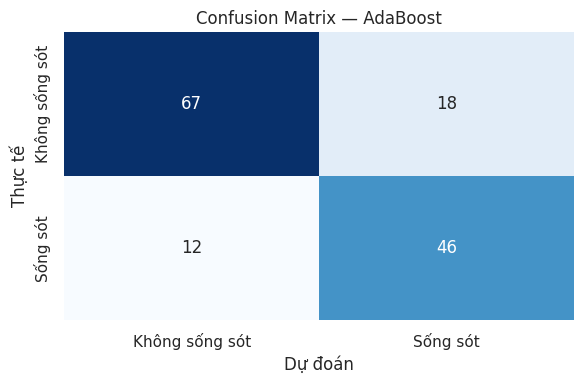


✅ Saved classification report -> classification_report_AdaBoost_20251102_024603.txt
✅ Saved confusion matrix image -> confusion_matrix_AdaBoost_20251102_024603.png


In [31]:
# === Detailed evaluation for the chosen best model (Classification report + Confusion matrix) ===
import joblib
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.validation import check_is_fitted
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from datetime import datetime

# Lấy tên và đường dẫn model tốt nhất từ df_eval và model_files
best_model_name = df_eval.iloc[0]['Model']
best_model_path = model_files[best_model_name]
print(f"Selected best model from df_eval: {best_model_name}")
print(f"Loading model file: {best_model_path}")

# Load model
best_model = joblib.load(best_model_path)

# Nếu model chưa được fit (không fitted), fit tạm trên X_train để có thể đánh giá trên X_val
try:
    # check_is_fitted sẽ raise nếu chưa fit
    check_is_fitted(best_model)
    fitted_ok = True
except Exception:
    fitted_ok = False

if not fitted_ok:
    print("Model chưa được fit. Sẽ huấn luyện tạm trên X_train để có thể đánh giá trên X_val.")
    best_model.fit(X_train, y_train)
else:
    print("Model đã fit — sẵn sàng predict trên X_val.")

# Predict trên validation set
y_val_pred = best_model.predict(X_val)

# Accuracy
acc = accuracy_score(y_val, y_val_pred)
print(f"\n✅ Accuracy trên X_val: {acc:.4f}\n")

# Classification report (với tên lớp rõ ràng)
target_names = ["Không sống sót", "Sống sót"]
creport = classification_report(y_val, y_val_pred, target_names=target_names)
print("📋 Classification Report:\n")
print(creport)

# Confusion matrix và heatmap
cm = confusion_matrix(y_val, y_val_pred)
cm_df = pd.DataFrame(cm, index=target_names, columns=target_names)

plt.figure(figsize=(6,4))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f"Confusion Matrix — {best_model_name}")
plt.ylabel('Thực tế')
plt.xlabel('Dự đoán')
plt.tight_layout()
plt.show()

# --- (Tùy chọn) Lưu report + hình để chèn slide ---
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
report_txt = f"classification_report_{best_model_name.replace(' ','_')}_{timestamp}.txt"
with open(report_txt, "w", encoding="utf-8") as f:
    f.write(f"Model: {best_model_name}\n")
    f.write(f"Accuracy on X_val: {acc:.4f}\n\n")
    f.write(creport)

# Lưu hình ma trận
fig_path = f"confusion_matrix_{best_model_name.replace(' ','_')}_{timestamp}.png"
plt.figure(figsize=(6,4))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f"Confusion Matrix — {best_model_name}")
plt.ylabel('Thực tế')
plt.xlabel('Dự đoán')
plt.tight_layout()
plt.savefig(fig_path, dpi=200)
plt.close()

print(f"\n✅ Saved classification report -> {report_txt}")
print(f"✅ Saved confusion matrix image -> {fig_path}")




#5. dự đoán trên TEST SET + lưu submission.csv

In [32]:
from datetime import datetime
from IPython.display import display, HTML
import pandas as pd

# Nhật ký text
test_text = ">>>  Prediction on Test Set\n\n"

# 1) Lấy X_test đúng cột
X_test = test_df[feature_cols]

test_text += f"Số lượng mẫu test: {len(X_test)}\n"
test_text += f"Feature columns dùng cho test: {feature_cols}\n\n"

# 2) Load final model đã train full data ở Cell 8
final_model = joblib.load("titanic_final_model.joblib")
test_text += "Final model loaded: titanic_final_model.joblib\n\n"

# 3) Predict
test_pred = final_model.predict(X_test)
test_text += "Dự đoán test thành công.\n"

# 4) Tạo dataframe kết quả tạm (không phải submission)
test_result = pd.DataFrame({
    "PassengerId": test_df.index,
    "Predicted_Survived": test_pred
})

# 5) Lưu kết quả dự đoán ra file CSV nội bộ
test_result.to_csv("test_predictions.csv", index=False)
test_text += "Đã lưu file test_predictions.csv\n\n"

# 6) Lưu HTML log
title = datetime.now().strftime("%Y-%m-%d") + "_Test_Prediction"
save_html_log(title, test_text)

display(HTML("<h3 style='color: green;'>✅ CELL 9 DONE — Test prediction hoàn tất.</h3>"))
display(HTML("<h4>Kết quả dự đoán (5 hàng đầu tiên):</h4>"))

# --- Tạo kiểu cho bảng test_result.head() ---
table_styles = [
    {
        'selector': 'th',
        'props': [
            ('background-color', '#0d47a1'),
            ('color', 'white'),
            ('text-align', 'center'),
            ('font-size', '11pt')
        ]
    },
    {
        'selector': 'td',
        'props': [
            ('background-color', '#f4f6f8'),
            ('color', 'black'),
            ('padding', '5px')
        ]
    },
    {
        'selector': 'td:nth-child(1)',
        'props': [('text-align', 'center'), ('font-weight', 'bold')]
    },
    {
        'selector': 'td:nth-child(2)',
        'props': [('text-align', 'center')]
    }
]

styled_test_head = (
    test_result.head().style
    .set_table_styles(table_styles)
    .hide()
)

display(styled_test_head)


✅ Đã lưu log HTML: html_logs/2025-11-02_Test_Prediction.html


PassengerId,Predicted_Survived
892,0
893,0
894,0
895,0
896,0


#Kết Luận

* Dựa trên kết quả đánh giá mô hình ở bước validation, Voting là mô hình đạt hiệu suất cao nhất với accuracy = 0.7902, vượt qua các mô hình khác về hiệu suất

* Điều này cho thấy Voting phù hợp với cấu trúc dữ liệu của Titanic, khi nó có khả năng kết hợp nhiều weak learners để bắt tốt các quan hệ phi tuyến nhưng vẫn tránh overfitting.

* Sau khi chọn Voting làm mô hình cuối, tôi đã huấn luyện lại mô hình trên toàn bộ dữ liệu train nhằm tận dụng toàn bộ thông tin, rồi dùng mô hình này để dự đoán trên tập test, kết quả được lưu trong file